In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/ems_results/'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

print("Setup OK")


Mounted at /content/drive
Setup OK


In [ ]:
# ============================================================
# CELL 2: BESS & EMS CONFIGURATION
# ============================================================

# === BESS Specs (DKP Microgrid) ===
BESS = {
    'capacity_kwh':       358.0,     # nameplate capacity
    'max_power_kw':       300.0,     # max charge/discharge power
    'eff_charge':         0.95,      # charging efficiency
    'eff_discharge':      0.95,      # discharging efficiency
    'soc_min':            0.20,      # minimum SoC (battery longevity)
    'soc_max':            0.90,      # maximum SoC
    'soc_initial':        0.50,      # starting SoC
}

# Derived
BESS['usable_capacity_kwh'] = BESS['capacity_kwh'] * (BESS['soc_max'] - BESS['soc_min'])
BESS['roundtrip_eff']       = BESS['eff_charge'] * BESS['eff_discharge']

# === EMS Strategy ===
EMS_CFG = {
    'peak_threshold_kw':  150.0,     # peak shaving threshold
    'timestep_hours':     1.0,       # hourly resolution
}

print("="*60)
print(" BESS SPECIFICATIONS")
print("="*60)
print(f"  Capacity:           {BESS['capacity_kwh']:.1f} kWh")
print(f"  Max Power:          {BESS['max_power_kw']:.1f} kW")
print(f"  Round-trip eff.:    {BESS['roundtrip_eff']*100:.1f}%")
print(f"  SoC range:          {BESS['soc_min']*100:.0f}% - {BESS['soc_max']*100:.0f}%")
print(f"  Usable capacity:    {BESS['usable_capacity_kwh']:.1f} kWh")
print(f"  Initial SoC:        {BESS['soc_initial']*100:.0f}% ({BESS['soc_initial']*BESS['capacity_kwh']:.1f} kWh)")

print(f"\n{'='*60}")
print(" EMS STRATEGY")
print("="*60)
print(f"  Peak shaving threshold: {EMS_CFG['peak_threshold_kw']:.0f} kW")
print(f"  Timestep:               {EMS_CFG['timestep_hours']:.1f} hour")
print(f"  Objective:              Self-consumption + Peak shaving")


 BESS SPECIFICATIONS
  Capacity:           358.0 kWh
  Max Power:          300.0 kW
  Round-trip eff.:    90.2%
  SoC range:          20% - 90%
  Usable capacity:    250.6 kWh
  Initial SoC:        50% (179.0 kWh)

 EMS STRATEGY
  Peak shaving threshold: 150 kW
  Timestep:               1.0 hour
  Objective:              Self-consumption + Peak shaving


In [ ]:
# ============================================================
# CELL 3: ΦΟΡΤΩΣΗ ALIGNED DAY-AHEAD PREDICTIONS
# ============================================================

# === PV Day-Ahead (LSTM enc-dec - winner) ===
pv_da = pd.read_csv(PRED_DIR + 'pv_24h_predictions_gpu_aligned.csv')
pv_da['timestamp'] = pd.to_datetime(pv_da['timestamp'])
pv_da = pv_da.set_index('timestamp').sort_index()

pv_da['pv_actual']    = pv_da['actual'].clip(lower=0)
pv_da['pv_predicted'] = pv_da['predicted_lstm'].clip(lower=0)   # LSTM = best

print("="*70)
print(" PV DAY-AHEAD PREDICTIONS LOADED (ALIGNED)")
print("="*70)
print(f"Rows: {len(pv_da):,}")
print(f"Range: {pv_da.index.min()}  ->  {pv_da.index.max()}")
print(f"Actual mean:    {pv_da['pv_actual'].mean():.2f} kW")
print(f"Predicted mean: {pv_da['pv_predicted'].mean():.2f} kW")
print(f"Model: LSTM encoder-decoder")

# === Load Day-Ahead (LSTM enc-dec - νέο best μετά το alignment) ===
load_da = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')
load_da['timestamp'] = pd.to_datetime(load_da['timestamp'])
load_da = load_da.set_index('timestamp').sort_index()

load_da['load_actual']    = load_da['actual'].clip(lower=0)
load_da['load_predicted'] = load_da['predicted_lstm'].clip(lower=0)  # LSTM = νέο best

print(f"\n{'='*70}")
print(" LOAD DAY-AHEAD PREDICTIONS LOADED (ALIGNED)")
print("="*70)
print(f"Rows: {len(load_da):,}")
print(f"Range: {load_da.index.min()}  ->  {load_da.index.max()}")
print(f"Actual mean:    {load_da['load_actual'].mean():.2f} kW")
print(f"Predicted mean: {load_da['load_predicted'].mean():.2f} kW")
print(f"Model: LSTM encoder-decoder")

 PV DAY-AHEAD PREDICTIONS LOADED (ALIGNED)
Rows: 2,397
Range: 2025-05-19 14:00:00  ->  2025-09-03 19:00:00
Actual mean:    51.73 kW
Predicted mean: 51.83 kW
Model: LSTM encoder-decoder

 LOAD DAY-AHEAD PREDICTIONS LOADED (ALIGNED)
Rows: 2,397
Range: 2025-05-19 14:00:00  ->  2025-09-03 19:00:00
Actual mean:    75.90 kW
Predicted mean: 72.80 kW
Model: LSTM encoder-decoder


In [ ]:
# ============================================================
# CELL 4: MERGE PV + LOAD INTO COMMON TIMELINE
# ============================================================

df = pd.DataFrame(index=pv_da.index.intersection(load_da.index))
df['pv_actual']     = pv_da.loc[df.index, 'pv_actual']
df['pv_predicted']  = pv_da.loc[df.index, 'pv_predicted']
df['load_actual']    = load_da.loc[df.index, 'load_actual']
df['load_predicted'] = load_da.loc[df.index, 'load_predicted']

# Persistence forecast: αύριο = προχθές (same hour, 24h ago)
# Επειδή έχουμε ήδη hourly data, shift κατά 24 hours
df['pv_persistence']   = df['pv_actual'].shift(24)
df['load_persistence'] = df['load_actual'].shift(24)

# Drop NaN (πρώτη ημέρα του persistence)
df = df.dropna()

# === Computed: net load (Load - PV) ===
df['net_actual']      = df['load_actual']     - df['pv_actual']
df['net_predicted']   = df['load_predicted']  - df['pv_predicted']
df['net_persistence'] = df['load_persistence'] - df['pv_persistence']

print("="*70)
print(" COMMON TIMELINE")
print("="*70)
print(f"Total hours: {len(df):,}")
print(f"Total days:  {len(df) // 24}")
print(f"Range: {df.index.min()}  ->  {df.index.max()}")
print(f"\nNet Load statistics (Actual):")
print(f"  Mean: {df['net_actual'].mean():.2f} kW")
print(f"  Min:  {df['net_actual'].min():.2f} kW (max PV surplus)")
print(f"  Max:  {df['net_actual'].max():.2f} kW (max demand)")
print(f"  Hours with PV surplus (net<0): {(df['net_actual']<0).sum()} ({(df['net_actual']<0).mean()*100:.1f}%)")
print(f"  Hours over peak threshold ({EMS_CFG['peak_threshold_kw']:.0f} kW): {(df['net_actual']>EMS_CFG['peak_threshold_kw']).sum()} ({(df['net_actual']>EMS_CFG['peak_threshold_kw']).mean()*100:.1f}%)")


 COMMON TIMELINE
Total hours: 2,373
Total days:  98
Range: 2025-05-20 16:00:00  ->  2025-09-03 19:00:00

Net Load statistics (Actual):
  Mean: 24.07 kW
  Min:  -181.92 kW (max PV surplus)
  Max:  191.39 kW (max demand)
  Hours with PV surplus (net<0): 642 (27.1%)
  Hours over peak threshold (150 kW): 21 (0.9%)


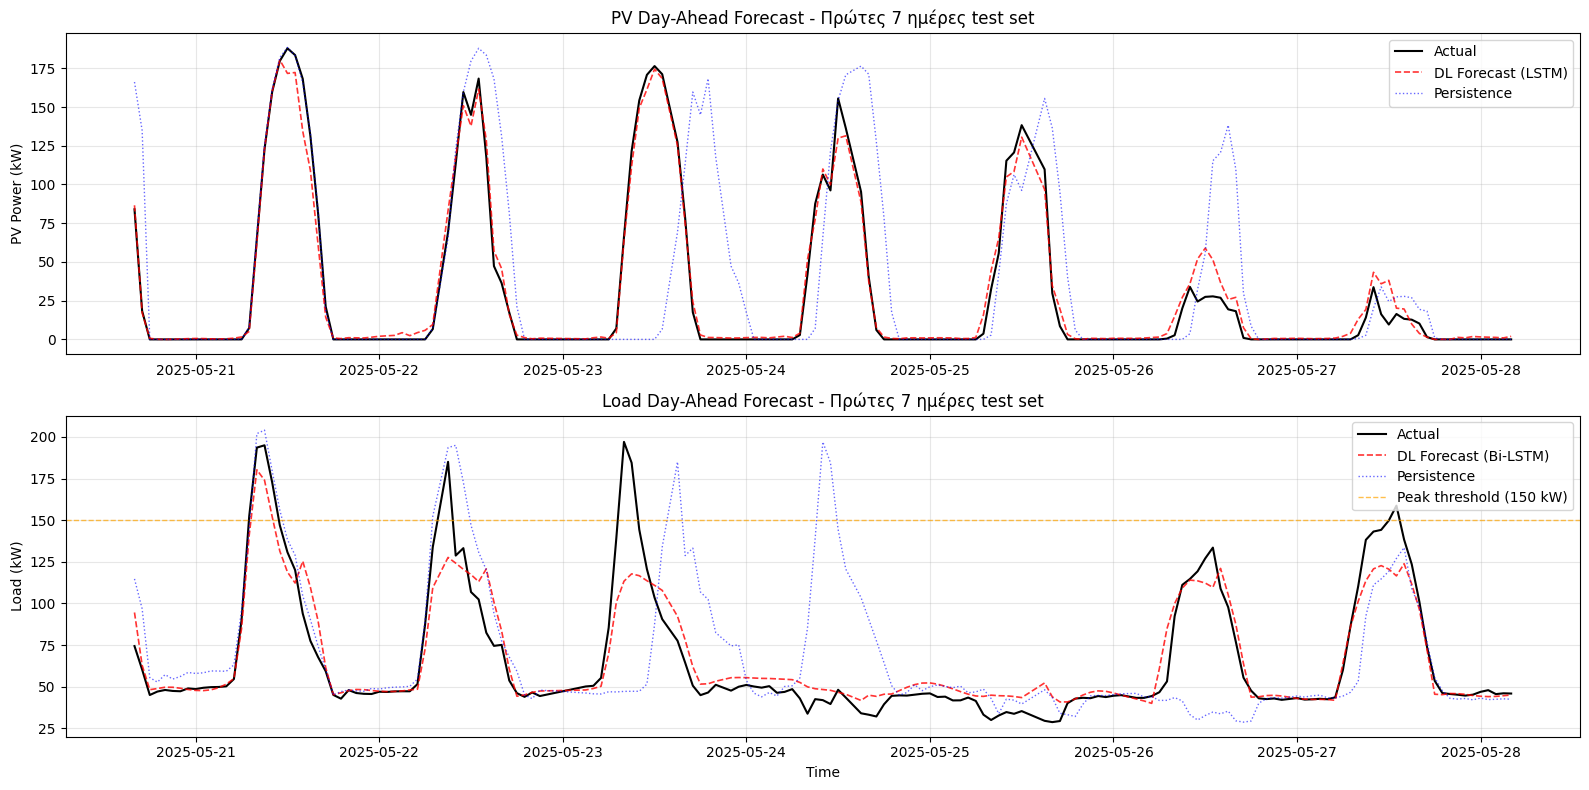

In [ ]:
# ============================================================
# CELL 5: FORECAST QUALITY VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Πρώτες 7 ημέρες
n_show = 24 * 7
sub = df.iloc[:n_show]

# PV
ax = axes[0]
ax.plot(sub.index, sub['pv_actual'],    'k-', lw=1.5, label='Actual')
ax.plot(sub.index, sub['pv_predicted'], 'r--', lw=1.2, label='DL Forecast (LSTM)', alpha=0.8)
ax.plot(sub.index, sub['pv_persistence'], 'b:', lw=1.0, label='Persistence', alpha=0.6)
ax.set_title(f'PV Day-Ahead Forecast - Πρώτες 7 ημέρες test set')
ax.set_ylabel('PV Power (kW)'); ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

# Load
ax = axes[1]
ax.plot(sub.index, sub['load_actual'],     'k-', lw=1.5, label='Actual')
ax.plot(sub.index, sub['load_predicted'],  'r--', lw=1.2, label='DL Forecast (Bi-LSTM)', alpha=0.8)
ax.plot(sub.index, sub['load_persistence'],'b:', lw=1.0, label='Persistence', alpha=0.6)
ax.axhline(EMS_CFG['peak_threshold_kw'], color='orange', linestyle='--', lw=1, alpha=0.7,
           label=f"Peak threshold ({EMS_CFG['peak_threshold_kw']:.0f} kW)")
ax.set_title(f'Load Day-Ahead Forecast - Πρώτες 7 ημέρες test set')
ax.set_ylabel('Load (kW)'); ax.set_xlabel('Time')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'forecast_quality.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# CELL: ΟΡΙΣΜΟΣ compute_kpis()
# ============================================================
def compute_kpis(sim, dt=1.0, peak_thr=150.0):
    """
    Υπολογίζει τα KPIs ενός σεναρίου EMS.
    """
    load_total = sim['load_actual'].sum() * dt
    pv_total   = sim['pv_actual'].sum() * dt
    grid_in    = sim['grid_import'].sum() * dt
    grid_out   = sim['grid_export'].sum() * dt
    pv_local   = sim['pv_used_local'].sum() * dt

    # Self-Consumption Rate: % της PV παραγωγής που χρησιμοποιήθηκε επιτόπου
    scr = (pv_local / pv_total * 100) if pv_total > 0 else 0

    # Self-Sufficiency Rate: % του φορτίου που καλύφθηκε από τοπικούς πόρους
    ssr = ((load_total - grid_in) / load_total * 100) if load_total > 0 else 0

    # Peak grid import
    peak_grid = sim['grid_import'].max()

    # Hours over threshold
    hours_over_thr = (sim['grid_import'] > peak_thr).sum()

    # Battery cycles (ισοδύναμοι κύκλοι)
    bess_capacity = 358.0  # από BESS config
    energy_through_battery = np.abs(sim['p_battery']).sum() * dt
    cycles = energy_through_battery / (2 * bess_capacity)

    return {
        'PV Generation (kWh)':       pv_total,
        'Load Consumption (kWh)':    load_total,
        'PV Self-Consumed (kWh)':    pv_local,
        'Grid Import (kWh)':         grid_in,
        'Grid Export (kWh)':         grid_out,
        'SCR (%)':                   scr,
        'SSR (%)':                   ssr,
        'Peak Grid Import (kW)':     peak_grid,
        'Hours over threshold':      int(hours_over_thr),
        'Battery Cycles':            cycles,
    }

print("compute_kpis() ορίστηκε")

compute_kpis() ορίστηκε


In [ ]:
# ============================================================
# CELL 6 : EMS με Smart Anticipatory Charging
# ============================================================

# === Anticipatory Charging Config ===
ANTICIPATORY = {
    'enabled':              True,
    'night_hours':          set(range(22, 24)) | set(range(0, 6)),
    'morning_peak_hours':   set(range(6, 11)),
    'morning_peak_thr':     150.0,    # ΑΝΕΒΑΣΑ: μόνο όταν προβλέπεται peak >180 kW
    'target_soc':           0.85,     # ΧΑΜΗΛΩΣΑ: πιο μετριοπαθής στόχος 60%
    'max_total_import':     120.0,    # ΝΕΟ: συνολικό grid import (load+charge) max 120 kW
}

print(f"Anticipatory Charging (SMART): {'ENABLED' if ANTICIPATORY['enabled'] else 'DISABLED'}")
print(f"  Trigger: morning load forecast > {ANTICIPATORY['morning_peak_thr']} kW")
print(f"  Target SoC: {ANTICIPATORY['target_soc']*100:.0f}%")
print(f"  Max total grid import during anticipation: {ANTICIPATORY['max_total_import']} kW")


def simulate_ems(load_actual, pv_actual,
                 load_forecast, pv_forecast,
                 bess_cfg, ems_cfg,
                 timestamps=None, anticipatory_cfg=None):
    n = len(load_actual)
    dt = ems_cfg['timestep_hours']

    capacity   = bess_cfg['capacity_kwh']
    soc        = bess_cfg['soc_initial'] * capacity
    soc_min    = bess_cfg['soc_min']      * capacity
    soc_max    = bess_cfg['soc_max']      * capacity
    p_max      = bess_cfg['max_power_kw']
    eta_c      = bess_cfg['eff_charge']
    eta_d      = bess_cfg['eff_discharge']
    peak_thr   = ems_cfg['peak_threshold_kw']

    soc_history     = np.zeros(n)
    p_battery       = np.zeros(n)
    p_grid_import   = np.zeros(n)
    p_grid_export   = np.zeros(n)
    p_pv_used_local = np.zeros(n)
    p_pv_curtailed  = np.zeros(n)
    decision_log    = []

    use_ant = anticipatory_cfg is not None and anticipatory_cfg.get('enabled', False)

    for t in range(n):
        net_load_fc = load_forecast[t] - pv_forecast[t]
        decision = None
        p_charge_target = 0

        # --- Anticipatory check ---
        if use_ant and timestamps is not None:
            hour_now = timestamps[t].hour
            soc_pct  = soc / capacity

            if (hour_now in anticipatory_cfg['night_hours']
                and soc_pct < anticipatory_cfg['target_soc']):

                # Δες τα επόμενα 12 hours forecast load
                look_end = min(t + 12, n)
                future_load_fc = load_forecast[t:look_end]

                if len(future_load_fc) > 0 and np.max(future_load_fc) > anticipatory_cfg['morning_peak_thr']:
                    # SMART POWER LIMIT: total grid import (load + charge) < max_total
                    load_now = load_forecast[t]
                    max_charge_kw = max(0, anticipatory_cfg['max_total_import'] - load_now)

                    # Υπολόγισε πόση ενέργεια χρειάζεται για να φτάσει το target
                    energy_needed_kwh = (anticipatory_cfg['target_soc'] * capacity - soc) / eta_c
                    # Πόσες ώρες απομένουν μέχρι το morning peak
                    hours_until_peak = 1
                    for h_ahead in range(min(12, n - t)):
                        if timestamps[t + h_ahead].hour in anticipatory_cfg['morning_peak_hours']:
                            hours_until_peak = max(1, h_ahead)
                            break
                    # Διασπείρε τη φόρτιση
                    spread_charge_kw = energy_needed_kwh / hours_until_peak

                    p_charge_target = min(max_charge_kw, spread_charge_kw, p_max)
                    p_charge_target = max(0, p_charge_target)
                    if p_charge_target > 0.5:
                        decision = 'ANTICIPATE'

        # --- Κανονικά rules ---
        if decision is None:
            if net_load_fc < 0:
                p_charge_target = min(-net_load_fc, p_max)
                decision = 'CHARGE'
            elif net_load_fc > peak_thr:
                p_charge_target = -min(net_load_fc - peak_thr, p_max)
                decision = 'PEAK_SHAVE'
            else:
                p_charge_target = -min(net_load_fc, p_max) if net_load_fc > 0 else 0
                decision = 'SELF_CONSUME' if p_charge_target < 0 else 'IDLE'

        # --- SoC constraints ---
        if p_charge_target > 0:
            max_charge_kwh = (soc_max - soc) / eta_c
            actual_kw = min(p_charge_target, max_charge_kwh / dt)
            actual_kw = max(0, actual_kw)
            soc_new = soc + actual_kw * eta_c * dt
            p_batt = actual_kw
        elif p_charge_target < 0:
            max_discharge_kwh = (soc - soc_min) * eta_d
            actual_kw = min(-p_charge_target, max_discharge_kwh / dt)
            actual_kw = max(0, actual_kw)
            soc_new = soc - actual_kw * dt / eta_d
            p_batt = -actual_kw
        else:
            soc_new = soc
            p_batt = 0

        # --- Energy balance ---
        pv_real   = pv_actual[t]
        load_real = load_actual[t]

        if decision == 'ANTICIPATE':
            # Φόρτιση μπαταρίας: PV καλύπτει load πρώτα, μετά grid καλύπτει το battery
            pv_to_load = min(pv_real, load_real)
            pv_remaining = pv_real - pv_to_load
            load_remaining = load_real - pv_to_load
            # Battery charge gets pv_remaining first, then grid
            from_pv_to_batt = min(p_batt, pv_remaining)
            from_grid_to_batt = max(0, p_batt - pv_remaining)
            pv_export = pv_remaining - from_pv_to_batt
            grid_import = load_remaining + from_grid_to_batt
            grid_export = pv_export
            pv_used_local = pv_to_load + from_pv_to_batt
            pv_curtailed = 0
        elif p_batt > 0:
            pv_after_battery = max(0, pv_real - p_batt)
            shortage = max(0, p_batt - pv_real)
            net = load_real - pv_after_battery + shortage
            if net >= 0:
                grid_import = net
                grid_export = 0
                pv_used_local = min(pv_real, p_batt + load_real)
                pv_curtailed = 0
            else:
                grid_import = 0
                grid_export = -net
                pv_used_local = pv_real - grid_export
                pv_curtailed = 0
        elif p_batt < 0:
            net = load_real - pv_real - (-p_batt)
            if net >= 0:
                grid_import = net
                grid_export = 0
                pv_used_local = pv_real
                pv_curtailed = 0
            else:
                grid_import = 0
                grid_export = -net
                pv_used_local = pv_real - grid_export
                pv_curtailed = 0
        else:
            net = load_real - pv_real
            if net >= 0:
                grid_import = net
                grid_export = 0
                pv_used_local = pv_real
            else:
                grid_import = 0
                grid_export = -net
                pv_used_local = pv_real - grid_export
            pv_curtailed = 0

        soc_history[t]     = soc_new / capacity
        p_battery[t]       = p_batt
        p_grid_import[t]   = grid_import
        p_grid_export[t]   = grid_export
        p_pv_used_local[t] = max(0, pv_used_local)
        p_pv_curtailed[t]  = max(0, pv_curtailed)
        decision_log.append(decision)
        soc = soc_new

    return pd.DataFrame({
        'load_actual':   load_actual,
        'pv_actual':     pv_actual,
        'load_forecast': load_forecast,
        'pv_forecast':   pv_forecast,
        'soc':           soc_history,
        'p_battery':     p_battery,
        'grid_import':   p_grid_import,
        'grid_export':   p_grid_export,
        'pv_used_local': p_pv_used_local,
        'pv_curtailed':  p_pv_curtailed,
        'decision':      decision_log,
    })

print("EMS core (SMART Anticipatory) defined")

Anticipatory Charging (SMART): ENABLED
  Trigger: morning load forecast > 150.0 kW
  Target SoC: 85%
  Max total grid import during anticipation: 120.0 kW
EMS core (SMART Anticipatory) defined


In [ ]:
# ============================================================
# CELL 7: S1 - NO EMS (BASELINE)
# ============================================================
sim_s1 = pd.DataFrame({
    'load_actual':  df['load_actual'].values,
    'pv_actual':    df['pv_actual'].values,
    'soc':          np.full(len(df), 0.5),
    'p_battery':    np.zeros(len(df)),
    'grid_import':  np.maximum(0, df['load_actual'].values - df['pv_actual'].values),
    'grid_export':  np.maximum(0, df['pv_actual'].values - df['load_actual'].values),
    'pv_used_local': np.minimum(df['pv_actual'].values, df['load_actual'].values),
    'pv_curtailed': np.zeros(len(df)),
})
kpi_s1 = compute_kpis(sim_s1, dt=EMS_CFG['timestep_hours'], peak_thr=EMS_CFG['peak_threshold_kw'])

print("="*70)
print(" SCENARIO S1: NO EMS (BASELINE)")
print("="*70)
for k, v in kpi_s1.items():
    if isinstance(v, float):
        print(f"  {k:35s}: {v:>12.2f}")
    else:
        print(f"  {k:35s}: {v:>12}")

 SCENARIO S1: NO EMS (BASELINE)
  PV Generation (kWh)                :    122476.34
  Load Consumption (kWh)             :    179588.97
  PV Self-Consumed (kWh)             :     79056.38
  Grid Import (kWh)                  :    100532.60
  Grid Export (kWh)                  :     43419.97
  SCR (%)                            :        64.55
  SSR (%)                            :        44.02
  Peak Grid Import (kW)              :       191.39
  Hours over threshold               :           21
  Battery Cycles                     :         0.00


In [ ]:
# ============================================================
# CELL 8: S2 - PERFECT FORECAST + ANTICIPATORY
# ============================================================
sim_s2 = simulate_ems(
    load_actual   = df['load_actual'].values,
    pv_actual     = df['pv_actual'].values,
    load_forecast = df['load_actual'].values,
    pv_forecast   = df['pv_actual'].values,
    bess_cfg = BESS,
    ems_cfg  = EMS_CFG,
    timestamps      = df.index,
    anticipatory_cfg= ANTICIPATORY,
)
kpi_s2 = compute_kpis(sim_s2, dt=EMS_CFG['timestep_hours'], peak_thr=EMS_CFG['peak_threshold_kw'])

print("="*70)
print(" SCENARIO S2: PERFECT FORECAST + ANTICIPATORY")
print("="*70)
for k, v in kpi_s2.items():
    if isinstance(v, float):
        print(f"  {k:35s}: {v:>12.2f}")
    else:
        print(f"  {k:35s}: {v:>12}")

 SCENARIO S2: PERFECT FORECAST + ANTICIPATORY
  PV Generation (kWh)                :    122476.34
  Load Consumption (kWh)             :    179588.97
  PV Self-Consumed (kWh)             :    102340.55
  Grid Import (kWh)                  :     80980.73
  Grid Export (kWh)                  :     20135.80
  SCR (%)                            :        83.56
  SSR (%)                            :        54.91
  Peak Grid Import (kW)              :       181.30
  Hours over threshold               :           13
  Battery Cycles                     :       101.14


In [ ]:
# ============================================================
# CELL 9: S3 - PERSISTENCE + ANTICIPATORY
# ============================================================
sim_s3 = simulate_ems(
    load_actual   = df['load_actual'].values,
    pv_actual     = df['pv_actual'].values,
    load_forecast = df['load_persistence'].values,
    pv_forecast   = df['pv_persistence'].values,
    bess_cfg = BESS,
    ems_cfg  = EMS_CFG,
    timestamps      = df.index,
    anticipatory_cfg= ANTICIPATORY,
)
kpi_s3 = compute_kpis(sim_s3, dt=EMS_CFG['timestep_hours'], peak_thr=EMS_CFG['peak_threshold_kw'])

print("="*70)
print(" SCENARIO S3: PERSISTENCE + ANTICIPATORY")
print("="*70)
for k, v in kpi_s3.items():
    if isinstance(v, float):
        print(f"  {k:35s}: {v:>12.2f}")
    else:
        print(f"  {k:35s}: {v:>12}")

 SCENARIO S3: PERSISTENCE + ANTICIPATORY
  PV Generation (kWh)                :    122476.34
  Load Consumption (kWh)             :    179588.97
  PV Self-Consumed (kWh)             :     92874.10
  Grid Import (kWh)                  :     92100.26
  Grid Export (kWh)                  :     31374.94
  SCR (%)                            :        75.83
  SSR (%)                            :        48.72
  Peak Grid Import (kW)              :       215.33
  Hours over threshold               :           20
  Battery Cycles                     :        94.56


In [ ]:
# ============================================================
# CELL 10: S4 - DL FORECASTS + ANTICIPATORY
# ============================================================
sim_s4 = simulate_ems(
    load_actual   = df['load_actual'].values,
    pv_actual     = df['pv_actual'].values,
    load_forecast = df['load_predicted'].values,
    pv_forecast   = df['pv_predicted'].values,
    bess_cfg = BESS,
    ems_cfg  = EMS_CFG,
    timestamps      = df.index,
    anticipatory_cfg= ANTICIPATORY,
)
kpi_s4 = compute_kpis(sim_s4, dt=EMS_CFG['timestep_hours'], peak_thr=EMS_CFG['peak_threshold_kw'])

print("="*70)
print(" SCENARIO S4: DL FORECASTS + ANTICIPATORY ")
print("="*70)
for k, v in kpi_s4.items():
    if isinstance(v, float):
        print(f"  {k:35s}: {v:>12.2f}")
    else:
        print(f"  {k:35s}: {v:>12}")

 SCENARIO S4: DL FORECASTS + ANTICIPATORY 
  PV Generation (kWh)                :    122476.34
  Load Consumption (kWh)             :    179588.97
  PV Self-Consumed (kWh)             :     97455.56
  Grid Import (kWh)                  :     85687.64
  Grid Export (kWh)                  :     25699.54
  SCR (%)                            :        79.57
  SSR (%)                            :        52.29
  Peak Grid Import (kW)              :       211.45
  Hours over threshold               :           17
  Battery Cycles                     :        80.44


In [ ]:
# ============================================================
# CELL 11: KPI COMPARISON TABLE
# ============================================================
import pandas as pd

scenarios = {
    'S1: No EMS':           kpi_s1,
    'S2: Perfect FC':       kpi_s2,
    'S3: Persistence':      kpi_s3,
    'S4: DL Forecasts ':   kpi_s4,
}

# === KPI Table ===
print("="*100)
print(" EMS SCENARIOS - KPI COMPARISON")
print("="*100)
df_kpi = pd.DataFrame(scenarios)
print(df_kpi.round(2).to_string())

# === Improvements vs S1 ===
print("\n" + "="*100)
print(" IMPROVEMENTS vs S1 (No EMS)")
print("="*100)
print(f"{'Scenario':<25} {'ΔSCR':>10} {'ΔSSR':>10} {'Peak Reduce':>14} {'Grid Import Reduce':>20}")
print("-"*100)
for name, kpi in scenarios.items():
    if name == 'S1: No EMS':
        continue
    d_scr    = kpi['SCR (%)'] - kpi_s1['SCR (%)']
    d_ssr    = kpi['SSR (%)'] - kpi_s1['SSR (%)']
    peak_red = (1 - kpi['Peak Grid Import (kW)'] / kpi_s1['Peak Grid Import (kW)']) * 100
    grid_red = (1 - kpi['Grid Import (kWh)']     / kpi_s1['Grid Import (kWh)']) * 100
    print(f"{name:<25} {d_scr:>+9.2f}% {d_ssr:>+9.2f}% {peak_red:>+13.2f}% {grid_red:>+19.2f}%")

# === S4 vs S2 (capture rate) ===
print("\n" + "="*100)
print(" S4 vs S2: DL FORECASTS vs ORACLE")
print("="*100)
capture_scr = (kpi_s4['SCR (%)'] - kpi_s1['SCR (%)']) / (kpi_s2['SCR (%)'] - kpi_s1['SCR (%)']) * 100
capture_ssr = (kpi_s4['SSR (%)'] - kpi_s1['SSR (%)']) / (kpi_s2['SSR (%)'] - kpi_s1['SSR (%)']) * 100
print(f"  DL captures {capture_scr:.1f}% του oracle improvement σε SCR")
print(f"  DL captures {capture_ssr:.1f}% του oracle improvement σε SSR")

 EMS SCENARIOS - KPI COMPARISON
                        S1: No EMS  S2: Perfect FC  S3: Persistence  S4: DL Forecasts 
PV Generation (kWh)      122476.34       122476.34        122476.34          122476.34
Load Consumption (kWh)   179588.97       179588.97        179588.97          179588.97
PV Self-Consumed (kWh)    79056.38       102340.55         92874.10           97455.56
Grid Import (kWh)        100532.60        80980.73         92100.26           85687.64
Grid Export (kWh)         43419.97        20135.80         31374.94           25699.54
SCR (%)                      64.55           83.56            75.83              79.57
SSR (%)                      44.02           54.91            48.72              52.29
Peak Grid Import (kW)       191.39          181.30           215.33             211.45
Hours over threshold         21.00           13.00            20.00              17.00
Battery Cycles                0.00          101.14            94.56              80.44

 IMPROVEME

Sunny weekday selected:    2025-09-02
Cloudy weekend selected:   2025-06-14


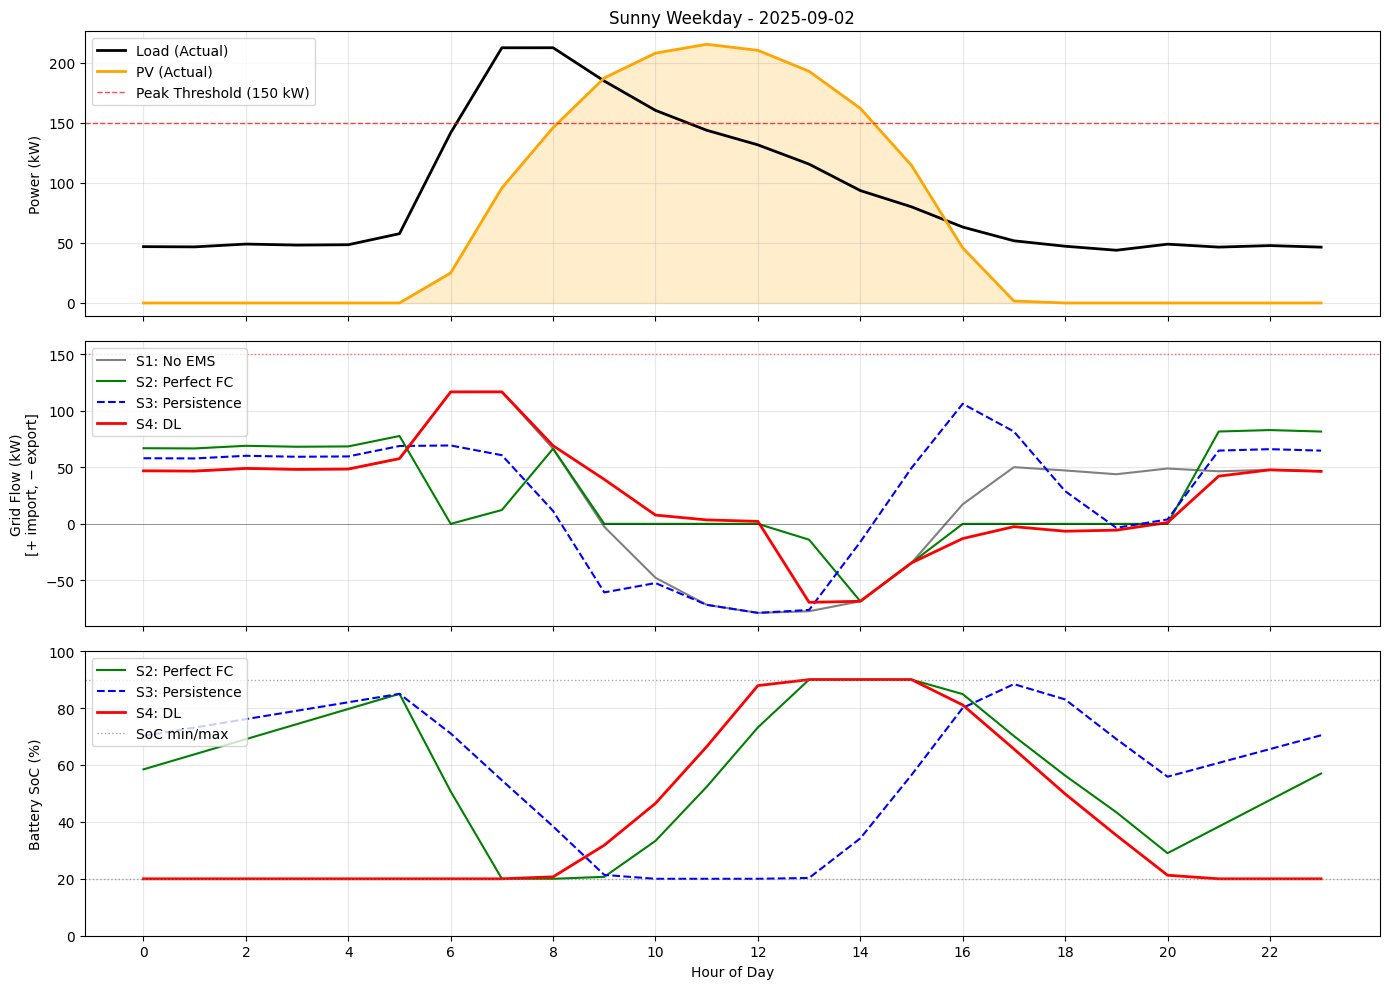

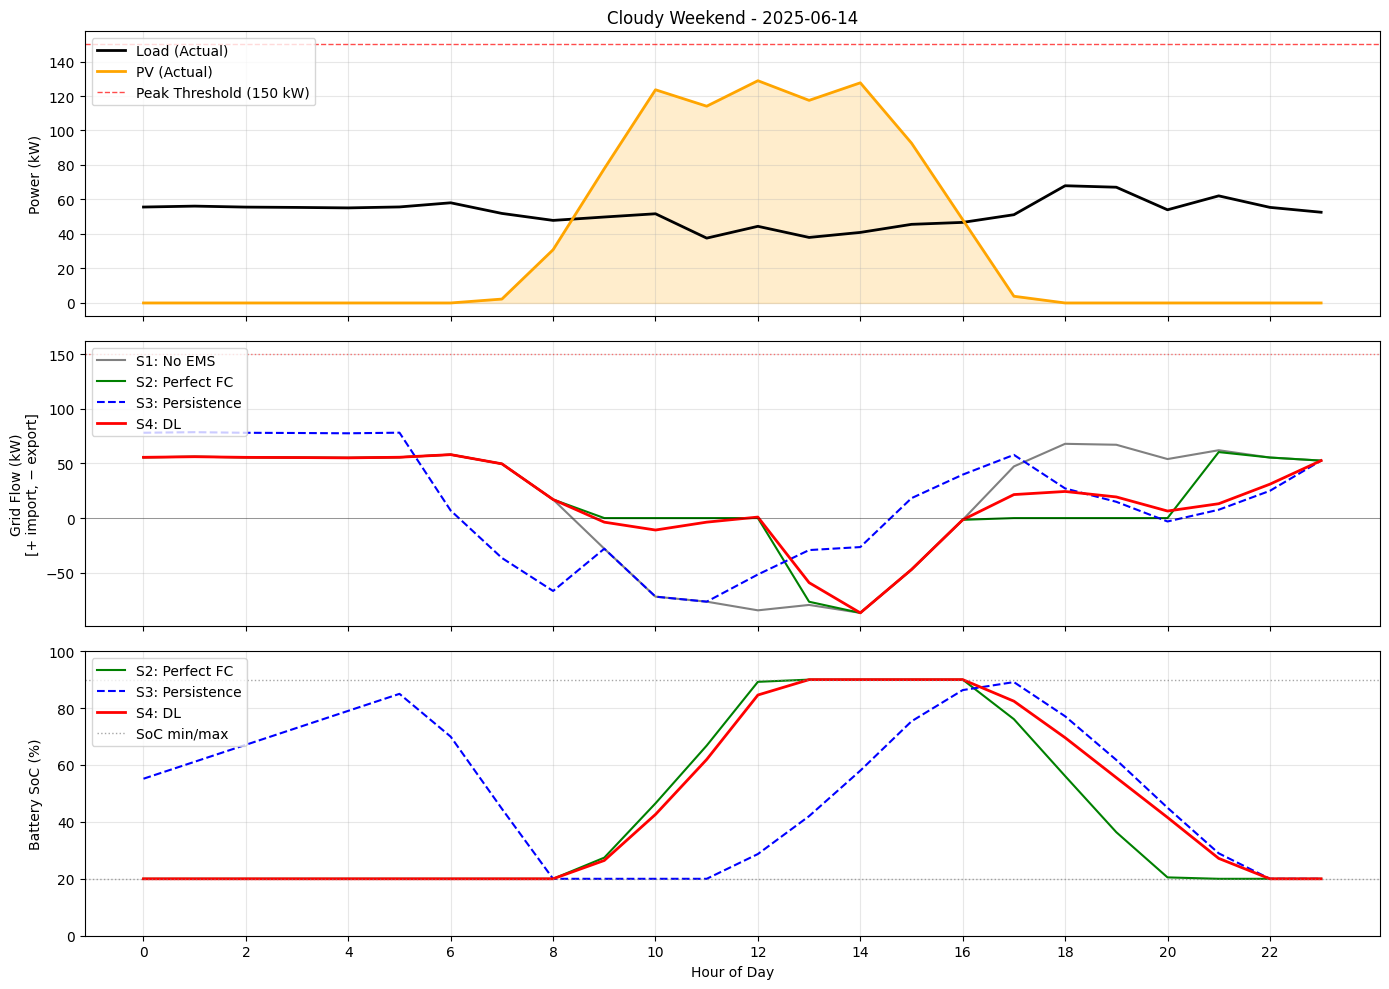

In [ ]:
# ============================================================
# CELL 12: VISUALIZATION - TYPICAL DAYS
# ============================================================

# === Find typical sunny weekday ===
df['date'] = df.index.date
df['dow']  = df.index.dayofweek
df['hour'] = df.index.hour

daily_pv  = df.groupby('date')['pv_actual'].sum()
daily_dow = df.groupby('date')['dow'].first()

# Sunny weekday = high PV, weekday (0-4) — αμετάβλητο
sunny_weekday_candidates = daily_pv[(daily_dow < 5) & (daily_pv > daily_pv.quantile(0.8))]
sunny_day = sunny_weekday_candidates.idxmax() if len(sunny_weekday_candidates) > 0 else daily_pv.idxmax()

# === Cloudy weekend = low PV, weekend (5,6), ΜΕ ΠΛΗΡΗ 24H ===
hours_per_day = df.groupby('date').size()
complete_days = set(hours_per_day[hours_per_day == 24].index)

# Φιλτράρισμα: μόνο Σαββατοκύριακα με 24 πλήρεις ώρες
weekend_complete_pv = daily_pv[(daily_dow >= 5) & (daily_pv.index.isin(complete_days))]
cloudy_weekend_candidates = weekend_complete_pv[weekend_complete_pv < weekend_complete_pv.quantile(0.4)]
cloudy_day = cloudy_weekend_candidates.idxmin() if len(cloudy_weekend_candidates) > 0 else weekend_complete_pv.idxmin()

print(f"Sunny weekday selected:    {sunny_day}")
print(f"Cloudy weekend selected:   {cloudy_day}")

def plot_day(target_date, title_suffix):
    mask = df['date'] == target_date
    if mask.sum() == 0:
        print(f"No data for {target_date}")
        return

    idx_start = np.where(mask)[0][0]
    idx_end   = idx_start + 24

    hours = np.arange(24)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # --- Top: Load, PV ---
    ax = axes[0]
    ax.plot(hours, df.iloc[idx_start:idx_end]['load_actual'].values, 'k-',  lw=2, label='Load (Actual)')
    ax.plot(hours, df.iloc[idx_start:idx_end]['pv_actual'].values,   'orange', lw=2, label='PV (Actual)')
    ax.axhline(EMS_CFG['peak_threshold_kw'], color='red', ls='--', lw=1, alpha=0.7,
               label=f"Peak Threshold ({EMS_CFG['peak_threshold_kw']:.0f} kW)")
    ax.fill_between(hours, 0, df.iloc[idx_start:idx_end]['pv_actual'].values, color='orange', alpha=0.2)
    ax.set_ylabel('Power (kW)')
    ax.set_title(f'{title_suffix} - {target_date}')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

    # --- Middle: Grid Flow (import positive, export negative) ---
    ax = axes[1]
    # Import → θετικές τιμές, Export → αρνητικές για να φαίνεται κάτω από το 0
    s1_net = sim_s1['grid_import'].values[idx_start:idx_end] - sim_s1['grid_export'].values[idx_start:idx_end]
    s2_net = sim_s2['grid_import'].values[idx_start:idx_end] - sim_s2['grid_export'].values[idx_start:idx_end]
    s3_net = sim_s3['grid_import'].values[idx_start:idx_end] - sim_s3['grid_export'].values[idx_start:idx_end]
    s4_net = sim_s4['grid_import'].values[idx_start:idx_end] - sim_s4['grid_export'].values[idx_start:idx_end]

    ax.plot(hours, s1_net, 'gray', lw=1.5, label='S1: No EMS')
    ax.plot(hours, s2_net, 'g-',   lw=1.5, label='S2: Perfect FC')
    ax.plot(hours, s3_net, 'b--',  lw=1.5, label='S3: Persistence')
    ax.plot(hours, s4_net, 'r-',   lw=2,   label='S4: DL')
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.5)
    ax.axhline(EMS_CFG['peak_threshold_kw'], color='red', ls=':', lw=1, alpha=0.5)
    ax.set_ylabel('Grid Flow (kW)\n[+ import, − export]')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

    # --- Bottom: SoC ---
    ax = axes[2]
    ax.plot(hours, sim_s2['soc'].values[idx_start:idx_end] * 100, 'g-',  lw=1.5, label='S2: Perfect FC')
    ax.plot(hours, sim_s3['soc'].values[idx_start:idx_end] * 100, 'b--', lw=1.5, label='S3: Persistence')
    ax.plot(hours, sim_s4['soc'].values[idx_start:idx_end] * 100, 'r-',  lw=2,   label='S4: DL')
    ax.axhline(BESS['soc_min']*100, color='gray', ls=':', lw=1, alpha=0.7, label='SoC min/max')
    ax.axhline(BESS['soc_max']*100, color='gray', ls=':', lw=1, alpha=0.7)
    ax.set_xlabel('Hour of Day'); ax.set_ylabel('Battery SoC (%)')
    ax.set_ylim(0, 100); ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"ems_day_{target_date}_{title_suffix.replace(' ', '_')}.png"
    plt.savefig(SAVE_DIR + fname, dpi=100, bbox_inches='tight')
    plt.show()

plot_day(sunny_day,  "Sunny Weekday")
plot_day(cloudy_day, "Cloudy Weekend")

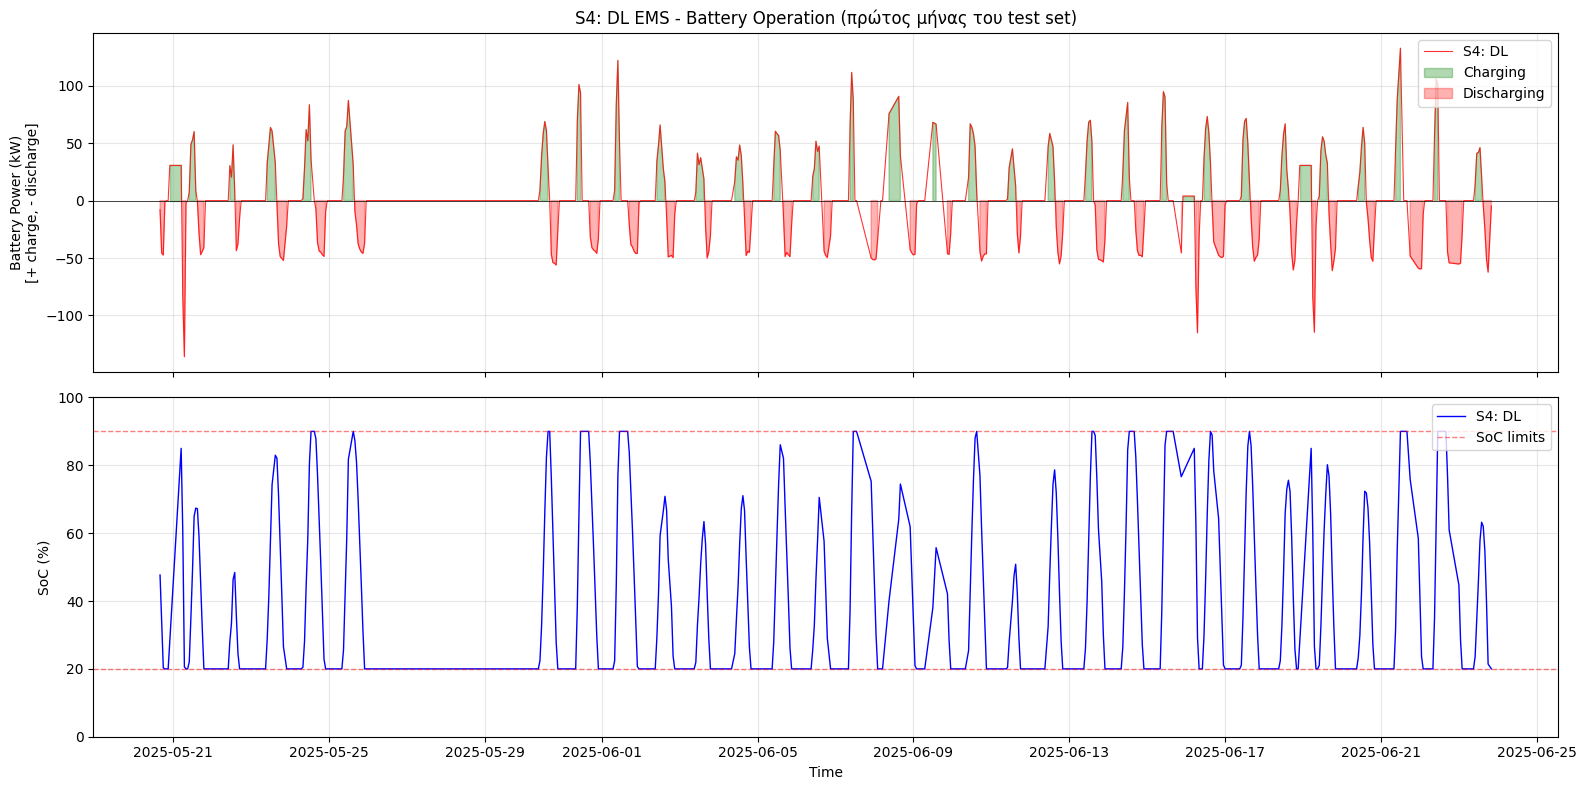

In [ ]:
# ============================================================
# CELL 13: LONG-TERM SoC PROFILE (1 MONTH)
# ============================================================

n_hours_plot = min(24 * 30, len(df))  # πρώτος μήνας

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: Battery power
ax = axes[0]
ax.plot(df.index[:n_hours_plot], sim_s4['p_battery'].values[:n_hours_plot],
        'r-', lw=0.8, alpha=0.8, label='S4: DL')
ax.axhline(0, color='k', lw=0.5)
ax.fill_between(df.index[:n_hours_plot], 0, sim_s4['p_battery'].values[:n_hours_plot],
                where=(sim_s4['p_battery'].values[:n_hours_plot] > 0),
                color='green', alpha=0.3, label='Charging')
ax.fill_between(df.index[:n_hours_plot], 0, sim_s4['p_battery'].values[:n_hours_plot],
                where=(sim_s4['p_battery'].values[:n_hours_plot] < 0),
                color='red',   alpha=0.3, label='Discharging')
ax.set_ylabel('Battery Power (kW)\n[+ charge, - discharge]')
ax.set_title('S4: DL EMS - Battery Operation (πρώτος μήνας του test set)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

# Bottom: SoC
ax = axes[1]
ax.plot(df.index[:n_hours_plot], sim_s4['soc'].values[:n_hours_plot]*100,
        'b-', lw=1, label='S4: DL')
ax.axhline(BESS['soc_min']*100, color='red', ls='--', lw=1, alpha=0.5, label='SoC limits')
ax.axhline(BESS['soc_max']*100, color='red', ls='--', lw=1, alpha=0.5)
ax.set_ylabel('SoC (%)'); ax.set_xlabel('Time'); ax.set_ylim(0, 100)
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'ems_monthly_battery_profile.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# CELL: ΕΥΘΥΓΡΑΜΜΙΣΗ ΟΛΩΝ ΤΩΝ TEST SETS ΣΕ ΚΟΙΝΟ ΔΙΑΣΤΗΜΑ
# Τρέξε το σε νέο notebook ή σε άδειο cell του EMS notebook
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'

# === Φόρτωση όλων ===
pv_cpu   = pd.read_csv(PRED_DIR + 'pv_24h_predictions_cpu.csv',   parse_dates=['timestamp']).set_index('timestamp').sort_index()
load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu.csv', parse_dates=['timestamp']).set_index('timestamp').sort_index()
pv_gpu   = pd.read_csv(PRED_DIR + 'pv_24h_predictions_gpu.csv',   parse_dates=['timestamp']).set_index('timestamp').sort_index()
load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu.csv', parse_dates=['timestamp']).set_index('timestamp').sort_index()

# === Resample CPU σε hourly για να ταιριάζει με GPU ===
pv_cpu_h   = pv_cpu.select_dtypes(include=[np.number]).resample('1h').mean()
load_cpu_h = load_cpu.select_dtypes(include=[np.number]).resample('1h').mean()
pv_gpu_h   = pv_gpu.select_dtypes(include=[np.number])
load_gpu_h = load_gpu.select_dtypes(include=[np.number])

# === Κοινή χρονική περίοδος ===
common_start = max(pv_cpu_h.index.min(), load_cpu_h.index.min(),
                   pv_gpu_h.index.min(), load_gpu_h.index.min())
common_end   = min(pv_cpu_h.index.max(), load_cpu_h.index.max(),
                   pv_gpu_h.index.max(), load_gpu_h.index.max())

print(f"=== ΚΟΙΝΟ TEST ΔΙΑΣΤΗΜΑ ===")
print(f"  Start: {common_start}")
print(f"  End:   {common_end}")
print(f"  Hours: {int((common_end - common_start).total_seconds() / 3600)}")

# === Κόψιμο όλων ===
pv_cpu_aligned   = pv_cpu_h.loc[common_start:common_end].dropna()
load_cpu_aligned = load_cpu_h.loc[common_start:common_end].dropna()
pv_gpu_aligned   = pv_gpu_h.loc[common_start:common_end].dropna()
load_gpu_aligned = load_gpu_h.loc[common_start:common_end].dropna()

# === Κρατάμε ΜΟΝΟ τα timestamps που υπάρχουν και στα 4 ===
common_idx = pv_cpu_aligned.index \
    .intersection(load_cpu_aligned.index) \
    .intersection(pv_gpu_aligned.index) \
    .intersection(load_gpu_aligned.index)

pv_cpu_aligned   = pv_cpu_aligned.loc[common_idx]
load_cpu_aligned = load_cpu_aligned.loc[common_idx]
pv_gpu_aligned   = pv_gpu_aligned.loc[common_idx]
load_gpu_aligned = load_gpu_aligned.loc[common_idx]

print(f"  Aligned rows: {len(common_idx)}")
print(f"  Aligned days: ~{len(common_idx)//24}")

# === Επαναϋπολογισμός μετρικών ===
def calc_metrics(y_true, y_pred, ref_range):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    nmae = mae / ref_range * 100
    return mae, rmse, r2, nmae

# === PV ===
print(f"\n{'='*70}")
print(f"  PV DAY-AHEAD - ΕΥΘΥΓΡΑΜΜΙΣΜΕΝΑ ΑΠΟΤΕΛΕΣΜΑΤΑ")
print(f"{'='*70}")
pv_range = pv_cpu_aligned['actual'].max() - pv_cpu_aligned['actual'].min()
print(f"{'Model':<25} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>8}")
print("-"*70)
for col, label in [('predicted_persist', 'Persistence (CPU)'),
                   ('predicted_rf',      'Random Forest (CPU)'),
                   ('predicted_xgb',     'XGBoost (CPU)')]:
    mae, rmse, r2, nmae = calc_metrics(pv_cpu_aligned['actual'], pv_cpu_aligned[col], pv_range)
    print(f"{label:<25} {mae:>10.3f} {rmse:>11.3f} {r2:>8.4f} {nmae:>7.2f}%")
for col, label in [('predicted_lstm',    'LSTM enc-dec (GPU)'),
                   ('predicted_cnnlstm', 'CNN-LSTM enc-dec (GPU)'),
                   ('predicted_bilstm',  'Bi-LSTM enc-dec (GPU)')]:
    mae, rmse, r2, nmae = calc_metrics(pv_gpu_aligned['actual'], pv_gpu_aligned[col], pv_range)
    print(f"{label:<25} {mae:>10.3f} {rmse:>11.3f} {r2:>8.4f} {nmae:>7.2f}%")

# === LOAD ===
print(f"\n{'='*70}")
print(f"  LOAD DAY-AHEAD - ΕΥΘΥΓΡΑΜΜΙΣΜΕΝΑ ΑΠΟΤΕΛΕΣΜΑΤΑ")
print(f"{'='*70}")
load_range = load_cpu_aligned['actual'].max() - load_cpu_aligned['actual'].min()
print(f"{'Model':<25} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>8}")
print("-"*70)
for col, label in [('predicted_persist', 'Persistence (CPU)'),
                   ('predicted_rf',      'Random Forest (CPU)'),
                   ('predicted_xgb',     'XGBoost (CPU)')]:
    mae, rmse, r2, nmae = calc_metrics(load_cpu_aligned['actual'], load_cpu_aligned[col], load_range)
    print(f"{label:<25} {mae:>10.3f} {rmse:>11.3f} {r2:>8.4f} {nmae:>7.2f}%")
for col, label in [('predicted_lstm',    'LSTM enc-dec (GPU)'),
                   ('predicted_cnnlstm', 'CNN-LSTM enc-dec (GPU)'),
                   ('predicted_bilstm',  'Bi-LSTM enc-dec (GPU)')]:
    mae, rmse, r2, nmae = calc_metrics(load_gpu_aligned['actual'], load_gpu_aligned[col], load_range)
    print(f"{label:<25} {mae:>10.3f} {rmse:>11.3f} {r2:>8.4f} {nmae:>7.2f}%")

# === Αποθήκευση aligned CSVs ===
pv_cpu_aligned['best_model']   = pv_cpu['best_model'].iloc[0] if 'best_model' in pv_cpu.columns else 'XGBoost'
load_cpu_aligned['best_model'] = load_cpu['best_model'].iloc[0] if 'best_model' in load_cpu.columns else 'XGBoost'
pv_gpu_aligned['best_model']   = 'LSTM'
load_gpu_aligned['best_model'] = 'Bi-LSTM'

# Άλλαξε ονόματα για συνέπεια
pv_cpu_aligned.to_csv(PRED_DIR + 'pv_24h_predictions_cpu_aligned.csv')
load_cpu_aligned.to_csv(PRED_DIR + 'load_24h_predictions_cpu_aligned.csv')
pv_gpu_aligned.to_csv(PRED_DIR + 'pv_24h_predictions_gpu_aligned.csv')
load_gpu_aligned.to_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')

print(f"\n{'='*70}")
print(f"✓ Aligned CSVs saved")
print(f"{'='*70}")

=== ΚΟΙΝΟ TEST ΔΙΑΣΤΗΜΑ ===
  Start: 2025-05-19 14:00:00
  End:   2025-09-03 19:00:00
  Hours: 2573
  Aligned rows: 2397
  Aligned days: ~99

  PV DAY-AHEAD - ΕΥΘΥΓΡΑΜΜΙΣΜΕΝΑ ΑΠΟΤΕΛΕΣΜΑΤΑ
Model                       MAE (kW)   RMSE (kW)       R²   nMAE %
----------------------------------------------------------------------
Persistence (CPU)              5.092      16.622   0.9460    2.28%
Random Forest (CPU)            3.576       9.673   0.9817    1.60%
XGBoost (CPU)                  3.870       9.806   0.9812    1.73%
LSTM enc-dec (GPU)             3.594       6.453   0.9918    1.61%
CNN-LSTM enc-dec (GPU)        20.416      39.888   0.6873    9.14%
Bi-LSTM enc-dec (GPU)         15.413      22.301   0.9023    6.90%

  LOAD DAY-AHEAD - ΕΥΘΥΓΡΑΜΜΙΣΜΕΝΑ ΑΠΟΤΕΛΕΣΜΑΤΑ
Model                       MAE (kW)   RMSE (kW)       R²   nMAE %
----------------------------------------------------------------------
Persistence (CPU)             43.813      62.855  -0.8601   17.40%
Random Forest (CPU

Range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00
Total hourly rows: 2397

Επιλεγμένες ηλιόλουστες ημέρες (Aligned PV CPU):
  2025-05-20 - max PV: 188.5 kW
  2025-05-21 - max PV: 187.8 kW
  2025-05-30 - max PV: 183.9 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/pv_da_cpu_3days.png


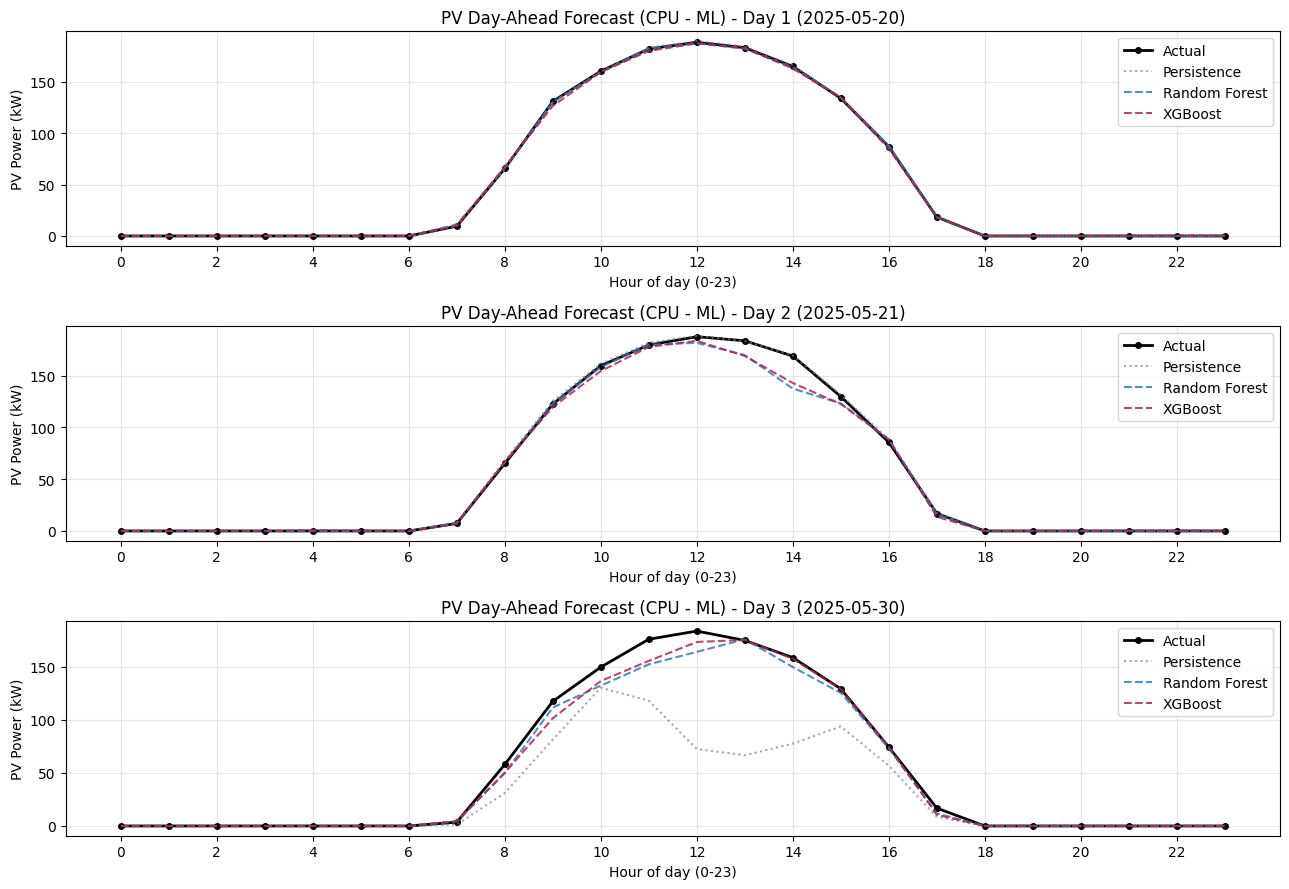


>>> PV dates για χρήση στο GPU: ['2025-05-20', '2025-05-21', '2025-05-30']


In [ ]:
# ============================================================
# CELL: PV CPU DAY-AHEAD - 3 ηλιόλουστες ημέρες (aligned)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

# Load aligned CSV
pv_cpu = pd.read_csv(PRED_DIR + 'pv_24h_predictions_cpu_aligned.csv')
pv_cpu['timestamp'] = pd.to_datetime(pv_cpu['timestamp'])
pv_cpu = pv_cpu.set_index('timestamp').sort_index()

print(f"Range: {pv_cpu.index.min()} -> {pv_cpu.index.max()}")
print(f"Total hourly rows: {len(pv_cpu)}")

# === Βρες 3 ηλιόλουστες ημέρες (max PV > 150 kW, ξεκινά 00:00) ===
day_starts = pv_cpu[pv_cpu.index.hour == 0].index
SUNNY_THRESHOLD = 150
sunny_starts = []

for ts in day_starts:
    day_slice = pv_cpu.loc[ts : ts + pd.Timedelta(hours=23)]
    if len(day_slice) == 24 and day_slice['actual'].max() > SUNNY_THRESHOLD:
        sunny_starts.append(ts)
    if len(sunny_starts) >= 3:
        break

print(f"\nΕπιλεγμένες ηλιόλουστες ημέρες (Aligned PV CPU):")
for s in sunny_starts:
    d = pv_cpu.loc[s : s + pd.Timedelta(hours=23)]
    print(f"  {s.strftime('%Y-%m-%d')} - max PV: {d['actual'].max():.1f} kW")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    if i >= len(sunny_starts):
        break
    start_ts = sunny_starts[i]
    sub = pv_cpu.loc[start_ts : start_ts + pd.Timedelta(hours=23)]
    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',        marker='o', markersize=4)
    ax.plot(hours, sub['predicted_persist'].values, ':',   lw=1.5, label='Persistence',   alpha=0.7,  color='gray')
    ax.plot(hours, sub['predicted_rf'].values,      '--',  lw=1.5, label='Random Forest', alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_xgb'].values,     '--',  lw=1.5, label='XGBoost',       alpha=0.85, color='#a52a5a')

    ax.set_title(f'PV Day-Ahead Forecast (CPU - ML) - Day {i+1} ({day_label})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('PV Power (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'pv_da_cpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

# Κράτα τις ημέρες για το GPU plot
pv_dates = [ts.strftime('%Y-%m-%d') for ts in sunny_starts]
print(f"\n>>> PV dates για χρήση στο GPU: {pv_dates}")

Range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00
Using dates from CPU: ['2025-05-20', '2025-05-21', '2025-05-30']

✓ Saved: /content/drive/MyDrive/Final_RUn/pv_da_gpu_3days.png


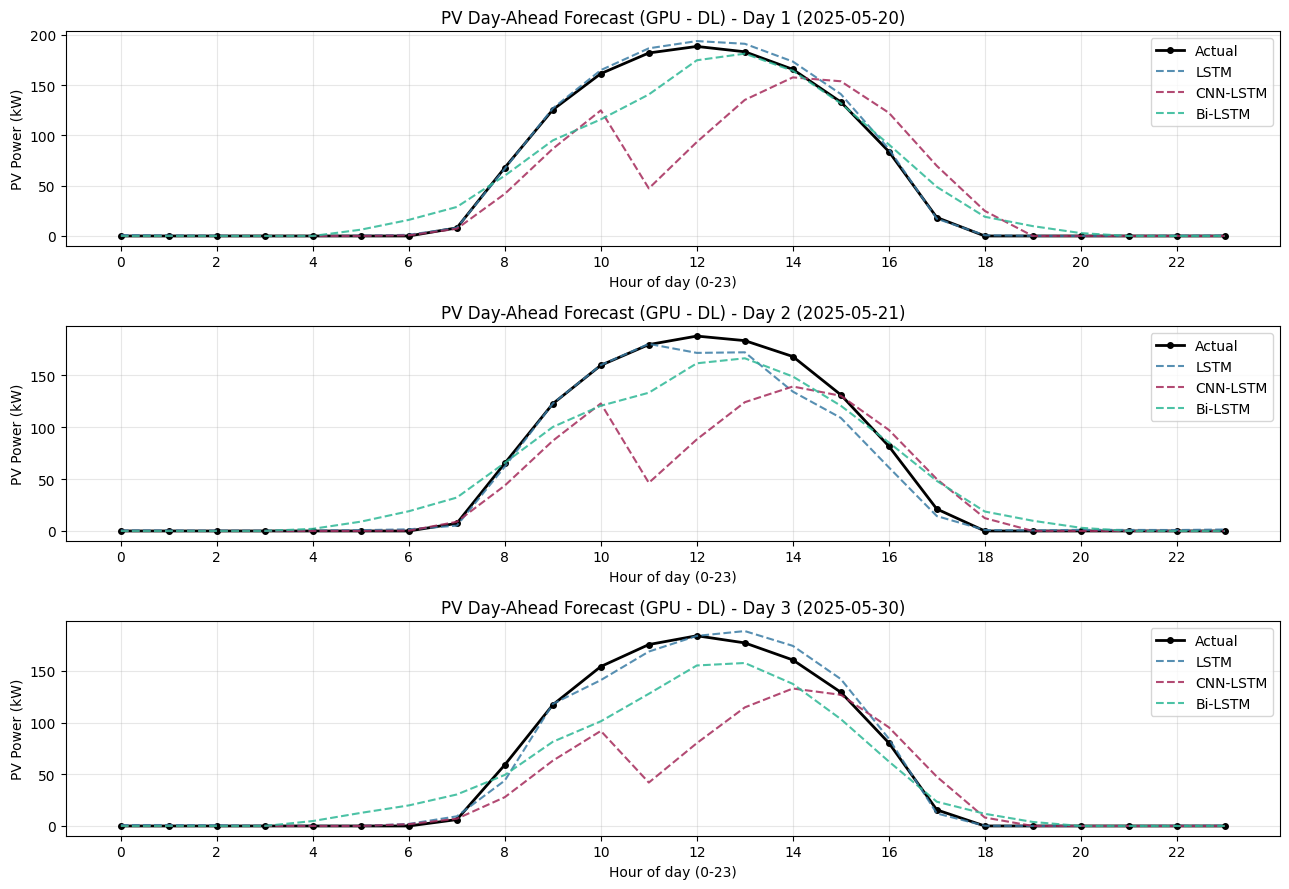

In [ ]:
# ============================================================
# CELL: PV GPU DAY-AHEAD - ίδιες ημέρες με CPU (aligned)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

pv_gpu = pd.read_csv(PRED_DIR + 'pv_24h_predictions_gpu_aligned.csv')
pv_gpu['timestamp'] = pd.to_datetime(pv_gpu['timestamp'])
pv_gpu = pv_gpu.set_index('timestamp').sort_index()

print(f"Range: {pv_gpu.index.min()} -> {pv_gpu.index.max()}")

# === Χρησιμοποίησε τις ΙΔΙΕΣ ημερομηνίες με το CPU (00:00-23:00 της κάθε μέρας) ===
# Αν δεν έχεις τρέξει το CPU cell, ορίστε τις χειροκίνητα
try:
    target_dates = [pd.Timestamp(d + ' 00:00:00') for d in pv_dates]
    print(f"Using dates from CPU: {pv_dates}")
except NameError:
    # Default: 3 ηλιόλουστες ημέρες
    day_starts = pv_gpu[pv_gpu.index.hour == 0].index
    target_dates = []
    for ts in day_starts:
        d = pv_gpu.loc[ts : ts + pd.Timedelta(hours=23)]
        if len(d) == 24 and d['actual'].max() > 150:
            target_dates.append(ts)
        if len(target_dates) >= 3:
            break
    print(f"Using auto-detected dates: {[d.strftime('%Y-%m-%d') for d in target_dates]}")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    if i >= len(target_dates):
        break
    start_ts = target_dates[i]
    sub = pv_gpu.loc[start_ts : start_ts + pd.Timedelta(hours=23)]

    if len(sub) < 24:
        print(f"⚠ Day {i+1} ({start_ts.date()}): μόνο {len(sub)} ώρες — skip")
        continue

    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',          marker='o', markersize=4)
    ax.plot(hours, sub['predicted_lstm'].values,    '--',  lw=1.5, label='LSTM',            alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_cnnlstm'].values, '--',  lw=1.5, label='CNN-LSTM',        alpha=0.85, color='#a52a5a')
    ax.plot(hours, sub['predicted_bilstm'].values,  '--',  lw=1.5, label='Bi-LSTM',         alpha=0.85, color='#2db896')

    ax.set_title(f'PV Day-Ahead Forecast (GPU - DL) - Day {i+1} ({day_label})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('PV Power (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'pv_da_gpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

CPU range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00
GPU range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00

Επιλεγμένη τριάδα ξεκινώντας: 2025-06-26 (Πέμπτη)
  Day 1: 2025-06-26 (Πέμπτη) - max Load: 221.9 kW
  Day 2: 2025-06-27 (Παρασκευή) - max Load: 196.5 kW
  Day 3: 2025-06-28 (Σάββατο) - max Load: 64.0 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_cpu_3days.png


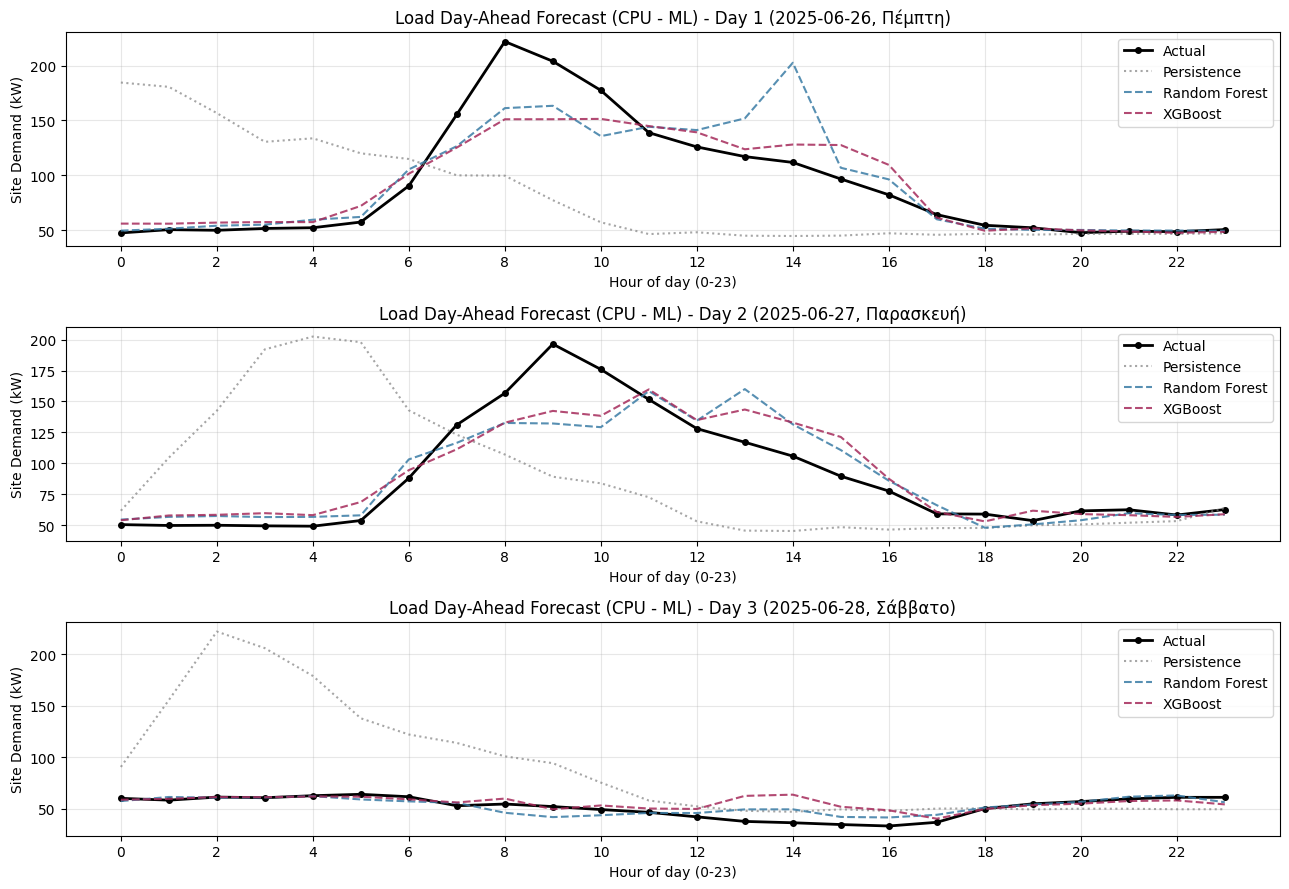


>>> Triplet start για Load GPU: 2025-06-26 00:00:00


In [ ]:
# ============================================================
# CELL: LOAD CPU DAY-AHEAD - Πέμπτη/Παρ/Σάββατο
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu_aligned.csv')
load_cpu['timestamp'] = pd.to_datetime(load_cpu['timestamp'])
load_cpu = load_cpu.set_index('timestamp').sort_index()

# Φόρτωσε και το GPU για να ελέγξουμε ότι ΚΑΙ ΤΑ ΔΥΟ έχουν πλήρη δεδομένα
load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')
load_gpu['timestamp'] = pd.to_datetime(load_gpu['timestamp'])
load_gpu = load_gpu.set_index('timestamp').sort_index()

print(f"CPU range: {load_cpu.index.min()} -> {load_cpu.index.max()}")
print(f"GPU range: {load_gpu.index.min()} -> {load_gpu.index.max()}")

# === Βρες πρώτη Πέμπτη με ΠΛΗΡΕΣ 72h ΚΑΙ στα δύο datasets ===
day_starts = load_cpu[load_cpu.index.hour == 0].index

triplet_start = None
for ts in day_starts:
    if ts.dayofweek != 3:  # Πέμπτη
        continue

    full_index = pd.date_range(ts, ts + pd.Timedelta(hours=71), freq='1h')

    # Έλεγχος στο CPU
    cpu_slice = load_cpu.reindex(full_index)
    cpu_missing = cpu_slice['actual'].isna().sum()

    # Έλεγχος στο GPU
    gpu_slice = load_gpu.reindex(full_index)
    gpu_missing = gpu_slice['actual'].isna().sum()

    if cpu_missing == 0 and gpu_missing == 0:
        # Επιπλέον έλεγχος: η Πέμπτη να είναι εργάσιμη (σαφές προφίλ)
        thu = cpu_slice.iloc[:24]
        if thu['actual'].max() > 150:
            # Το Σάββατο πρέπει να είναι «τυπικό» (χαμηλό)
            sat = cpu_slice.iloc[48:72]
            if sat['actual'].max() < 150:  # τυπικό σαββατιάτικο
                triplet_start = ts
                break

if triplet_start is None:
    # Αν δεν βρέθηκε τυπικό Σάββατο, πάρε ό,τι έχει πλήρη δεδομένα
    print("Δεν βρέθηκε τυπικό Σαββατοκύριακο, ψάχνω χωρίς αυτό το κριτήριο...")
    for ts in day_starts:
        if ts.dayofweek != 3:
            continue
        full_index = pd.date_range(ts, ts + pd.Timedelta(hours=71), freq='1h')
        cpu_slice = load_cpu.reindex(full_index)
        gpu_slice = load_gpu.reindex(full_index)
        if cpu_slice['actual'].isna().sum() == 0 and gpu_slice['actual'].isna().sum() == 0:
            thu = cpu_slice.iloc[:24]
            if thu['actual'].max() > 150:
                triplet_start = ts
                break

if triplet_start is None:
    raise RuntimeError("Δεν βρέθηκε καμιά πλήρης τριάδα")

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']
print(f"\nΕπιλεγμένη τριάδα ξεκινώντας: {triplet_start.strftime('%Y-%m-%d')} ({day_names[triplet_start.dayofweek]})")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    start_ts = triplet_start + pd.Timedelta(days=i)
    full_idx = pd.date_range(start_ts, start_ts + pd.Timedelta(hours=23), freq='1h')
    sub = load_cpu.reindex(full_idx)

    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')
    dname = day_names[start_ts.dayofweek]

    print(f"  Day {i+1}: {day_label} ({dname}) - max Load: {sub['actual'].max():.1f} kW")

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',        marker='o', markersize=4)
    ax.plot(hours, sub['predicted_persist'].values, ':',   lw=1.5, label='Persistence',   alpha=0.7,  color='gray')
    ax.plot(hours, sub['predicted_rf'].values,      '--',  lw=1.5, label='Random Forest', alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_xgb'].values,     '--',  lw=1.5, label='XGBoost',       alpha=0.85, color='#a52a5a')

    ax.set_title(f'Load Day-Ahead Forecast (CPU - ML) - Day {i+1} ({day_label}, {dname})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_cpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

load_triplet_start = triplet_start
print(f"\n>>> Triplet start για Load GPU: {load_triplet_start}")

Range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00
Using triplet start from Load CPU: 2025-06-26 00:00:00
  Day 1: 2025-06-26 (Πέμπτη) - max Load: 210.0 kW (missing: 0h)
  Day 2: 2025-06-27 (Παρασκευή) - max Load: 192.5 kW (missing: 0h)
  Day 3: 2025-06-28 (Σάββατο) - max Load: 63.7 kW (missing: 0h)

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_gpu_3days.png


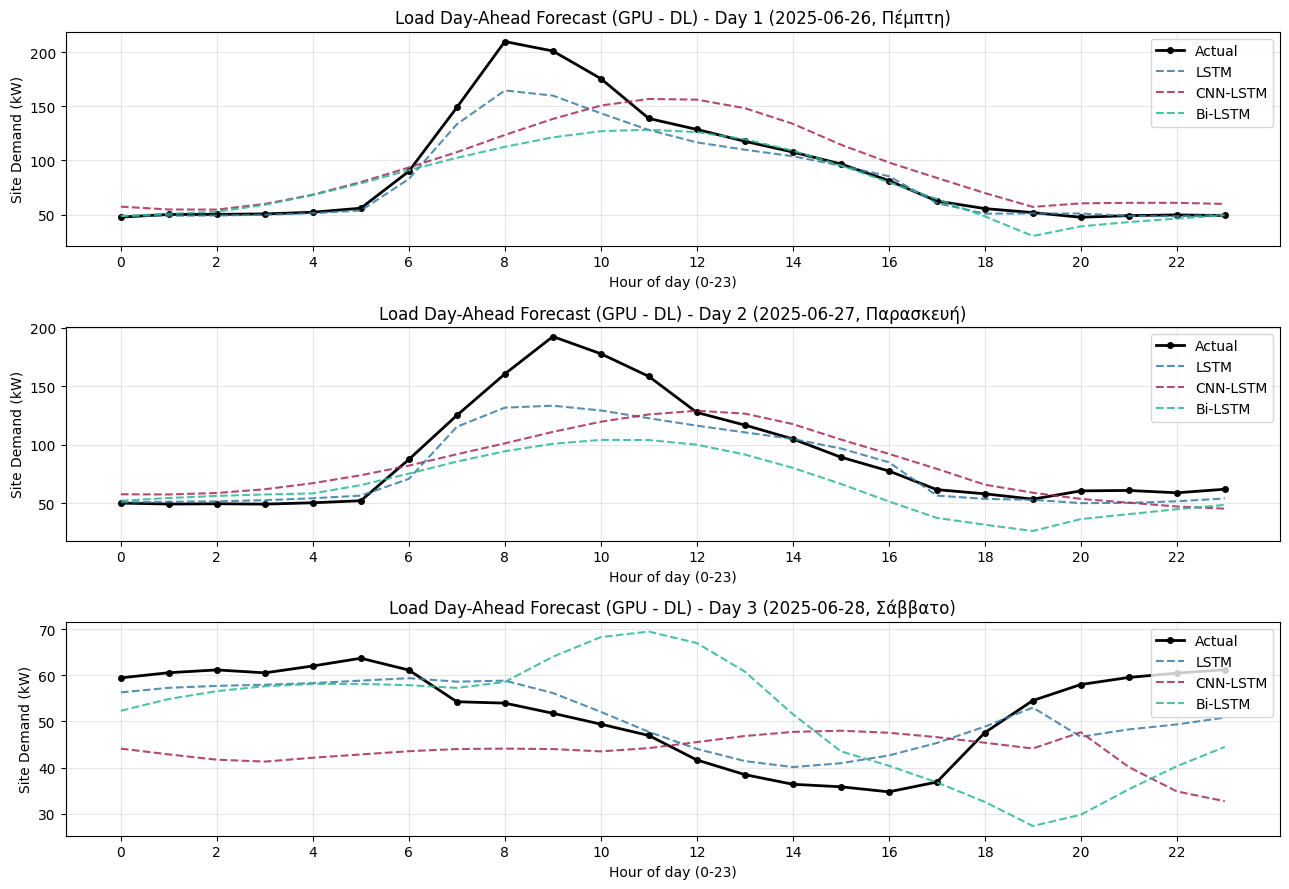

In [ ]:
# ============================================================
# CELL: LOAD GPU DAY-AHEAD - ίδιες ημέρες με CPU (aligned)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')
load_gpu['timestamp'] = pd.to_datetime(load_gpu['timestamp'])
load_gpu = load_gpu.set_index('timestamp').sort_index()

print(f"Range: {load_gpu.index.min()} -> {load_gpu.index.max()}")

# Χρησιμοποίησε ίδιες ημέρες με το CPU
try:
    triplet_start = load_triplet_start
    print(f"Using triplet start from Load CPU: {triplet_start}")
except NameError:
    raise RuntimeError("Τρέξε πρώτα το Load CPU cell ώστε να οριστεί η load_triplet_start")

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']

# === Plot με reindex για κενά ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    start_ts = triplet_start + pd.Timedelta(days=i)
    full_idx = pd.date_range(start_ts, start_ts + pd.Timedelta(hours=23), freq='1h')
    sub = load_gpu.reindex(full_idx)

    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')
    dname = day_names[start_ts.dayofweek]

    n_missing = sub['actual'].isna().sum()
    print(f"  Day {i+1}: {day_label} ({dname}) - max Load: {sub['actual'].max():.1f} kW (missing: {n_missing}h)")

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',   marker='o', markersize=4)
    ax.plot(hours, sub['predicted_lstm'].values,    '--',  lw=1.5, label='LSTM',     alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_cnnlstm'].values, '--',  lw=1.5, label='CNN-LSTM', alpha=0.85, color='#a52a5a')
    ax.plot(hours, sub['predicted_bilstm'].values,  '--',  lw=1.5, label='Bi-LSTM',  alpha=0.85, color='#2db896')

    ax.set_title(f'Load Day-Ahead Forecast (GPU - DL) - Day {i+1} ({day_label}, {dname})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_gpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

In [ ]:
import pandas as pd
PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'

load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu_aligned.csv')
load_cpu['timestamp'] = pd.to_datetime(load_cpu['timestamp'])
load_cpu = load_cpu.set_index('timestamp').sort_index()

# Δες την Τετάρτη 25 Ιουν 00:00-06:00
print("=== ΤΕΤΑΡΤΗ 25 Ιουν 2025 (νύχτα) ===")
wed = load_cpu.loc['2025-06-25 00:00':'2025-06-25 06:00', ['actual']]
print(wed)

# Δες τι λέει το persistence για την Πέμπτη 26 Ιουν 00:00-06:00
print("\n=== ΠΕΜΠΤΗ 26 Ιουν 2025 (νύχτα) ===")
thu = load_cpu.loc['2025-06-26 00:00':'2025-06-26 06:00', ['actual', 'predicted_persist']]
print(thu)

# Είναι το persistence = actual της προηγούμενης ημέρας;
print("\n=== Επαλήθευση: persistence(Πέμπτη) vs actual(Τετάρτη) ===")
print("Αν είναι ίδια → το persistence δουλεύει σωστά (απλά η Τετάρτη όντως είχε peak)")
print("Αν διαφέρουν → υπάρχει bug στο persistence calculation")

=== ΤΕΤΑΡΤΗ 25 Ιουν 2025 (νύχτα) ===
                        actual
timestamp                     
2025-06-25 00:00:00  46.667780
2025-06-25 01:00:00  45.841887
2025-06-25 02:00:00  47.224743
2025-06-25 03:00:00  46.437383
2025-06-25 04:00:00  46.499509
2025-06-25 05:00:00  50.453446
2025-06-25 06:00:00  86.010306

=== ΠΕΜΠΤΗ 26 Ιουν 2025 (νύχτα) ===
                        actual  predicted_persist
timestamp                                        
2025-06-26 00:00:00  47.446500         184.533144
2025-06-26 01:00:00  50.445894         180.592230
2025-06-26 02:00:00  49.838490         156.695873
2025-06-26 03:00:00  51.515330         130.505874
2025-06-26 04:00:00  52.175540         133.693659
2025-06-26 05:00:00  57.353076         119.998832
2025-06-26 06:00:00  90.388917         114.834295

=== Επαλήθευση: persistence(Πέμπτη) vs actual(Τετάρτη) ===
Αν είναι ίδια → το persistence δουλεύει σωστά (απλά η Τετάρτη όντως είχε peak)
Αν διαφέρουν → υπάρχει bug στο persistence calculation


CPU range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00

=== Έλεγχος: ΠΕΜΠΤΗ 26 Ιουν ===
                        actual  predicted_persist  persist_correct
2025-06-26 00:00:00  47.446500         184.533144        46.667780
2025-06-26 01:00:00  50.445894         180.592230        45.841887
2025-06-26 02:00:00  49.838490         156.695873        47.224743
2025-06-26 03:00:00  51.515330         130.505874        46.437383
2025-06-26 04:00:00  52.175540         133.693659        46.499509
2025-06-26 05:00:00  57.353076         119.998832        50.453446

Επιλεγμένη τριάδα ξεκινώντας: 2025-06-26 (Πέμπτη)
  Day 1: 2025-06-26 (Πέμπτη) - max Load: 221.9 kW
  Day 2: 2025-06-27 (Παρασκευή) - max Load: 196.5 kW
  Day 3: 2025-06-28 (Σάββατο) - max Load: 64.0 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_cpu_3days.png


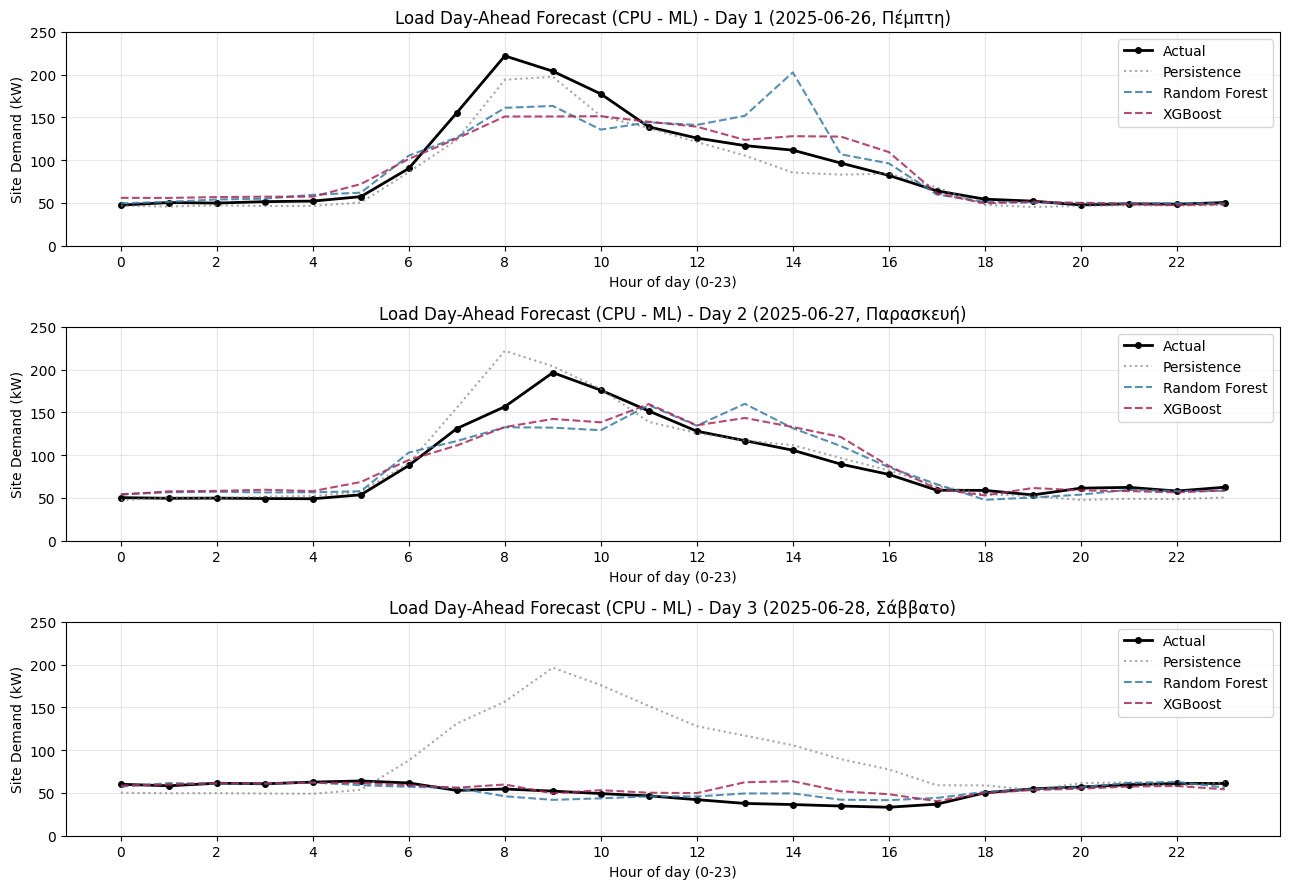

In [ ]:
# ============================================================
# CELL: LOAD CPU DAY-AHEAD με ΣΩΣΤΟ persistence
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu_aligned.csv')
load_cpu['timestamp'] = pd.to_datetime(load_cpu['timestamp'])
load_cpu = load_cpu.set_index('timestamp').sort_index()

# === ΥΠΟΛΟΓΙΣΜΟΣ ΣΩΣΤΟΥ PERSISTENCE: actual shifted by 24 hours ===
# Φτιάχνουμε ένα πλήρες hourly index για να μην έχει κενά
full_hourly = pd.date_range(load_cpu.index.min(), load_cpu.index.max(), freq='1h')
load_cpu_full = load_cpu.reindex(full_hourly)
load_cpu_full['persist_correct'] = load_cpu_full['actual'].shift(24)

print(f"CPU range: {load_cpu_full.index.min()} -> {load_cpu_full.index.max()}")

# Έλεγχος συσχέτισης παλιού vs νέου persistence
print("\n=== Έλεγχος: ΠΕΜΠΤΗ 26 Ιουν ===")
check = load_cpu_full.loc['2025-06-26 00:00':'2025-06-26 05:00', ['actual', 'predicted_persist', 'persist_correct']]
print(check)

# === Βρες την τριάδα Πεμ/Παρ/Σαβ (ίδια λογική όπως πριν) ===
load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')
load_gpu['timestamp'] = pd.to_datetime(load_gpu['timestamp'])
load_gpu = load_gpu.set_index('timestamp').sort_index()

day_starts = load_cpu_full[load_cpu_full.index.hour == 0].index
triplet_start = None
for ts in day_starts:
    if ts.dayofweek != 3:
        continue
    full_index = pd.date_range(ts, ts + pd.Timedelta(hours=71), freq='1h')
    cpu_slice = load_cpu_full.reindex(full_index)
    gpu_slice = load_gpu.reindex(full_index)
    if cpu_slice['actual'].isna().sum() == 0 and gpu_slice['actual'].isna().sum() == 0:
        thu = cpu_slice.iloc[:24]
        sat = cpu_slice.iloc[48:72]
        if thu['actual'].max() > 150 and sat['actual'].max() < 150:
            # Σιγουρέψου ότι ΚΑΙ το persistence είναι διαθέσιμο (24h πριν)
            if cpu_slice['persist_correct'].isna().sum() == 0:
                triplet_start = ts
                break

if triplet_start is None:
    raise RuntimeError("Δεν βρέθηκε κατάλληλη τριάδα")

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']
print(f"\nΕπιλεγμένη τριάδα ξεκινώντας: {triplet_start.strftime('%Y-%m-%d')} ({day_names[triplet_start.dayofweek]})")

# === Plot με ΣΩΣΤΟ persistence ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    start_ts = triplet_start + pd.Timedelta(days=i)
    full_idx = pd.date_range(start_ts, start_ts + pd.Timedelta(hours=23), freq='1h')
    sub = load_cpu_full.reindex(full_idx)

    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')
    dname = day_names[start_ts.dayofweek]

    print(f"  Day {i+1}: {day_label} ({dname}) - max Load: {sub['actual'].max():.1f} kW")

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',        marker='o', markersize=4)
    ax.plot(hours, sub['persist_correct'].values,   ':',   lw=1.5, label='Persistence',   alpha=0.7,  color='gray')
    ax.plot(hours, sub['predicted_rf'].values,      '--',  lw=1.5, label='Random Forest', alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_xgb'].values,     '--',  lw=1.5, label='XGBoost',       alpha=0.85, color='#a52a5a')

    ax.set_title(f'Load Day-Ahead Forecast (CPU - ML) - Day {i+1} ({day_label}, {dname})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.set_ylim(0, 250)   # κοινό y-range με GPU
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_cpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

load_triplet_start = triplet_start

Using triplet start from Load CPU: 2025-06-26 00:00:00
  Day 1: 2025-06-26 (Πέμπτη) - max Load: 210.0 kW
  Day 2: 2025-06-27 (Παρασκευή) - max Load: 192.5 kW
  Day 3: 2025-06-28 (Σάββατο) - max Load: 63.7 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_gpu_3days.png


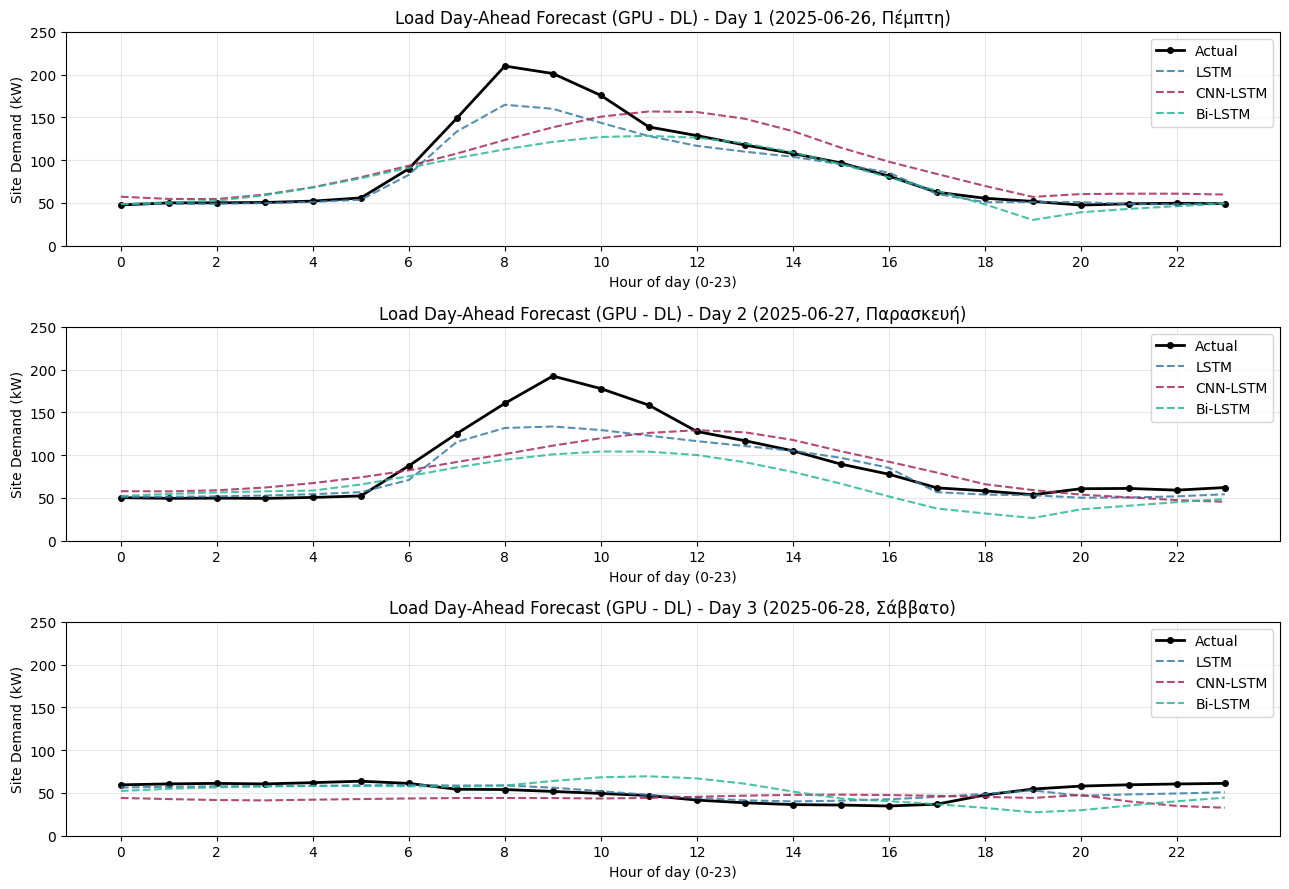

In [ ]:
# ============================================================
# CELL: LOAD GPU DAY-AHEAD με κοινό y-axis (0-250)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu_aligned.csv')
load_gpu['timestamp'] = pd.to_datetime(load_gpu['timestamp'])
load_gpu = load_gpu.set_index('timestamp').sort_index()

try:
    triplet_start = load_triplet_start
    print(f"Using triplet start from Load CPU: {triplet_start}")
except NameError:
    raise RuntimeError("Τρέξε πρώτα το Load CPU cell")

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    start_ts = triplet_start + pd.Timedelta(days=i)
    full_idx = pd.date_range(start_ts, start_ts + pd.Timedelta(hours=23), freq='1h')
    sub = load_gpu.reindex(full_idx)

    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')
    dname = day_names[start_ts.dayofweek]

    print(f"  Day {i+1}: {day_label} ({dname}) - max Load: {sub['actual'].max():.1f} kW")

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',   marker='o', markersize=4)
    ax.plot(hours, sub['predicted_lstm'].values,    '--',  lw=1.5, label='LSTM',     alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_cnnlstm'].values, '--',  lw=1.5, label='CNN-LSTM', alpha=0.85, color='#a52a5a')
    ax.plot(hours, sub['predicted_bilstm'].values,  '--',  lw=1.5, label='Bi-LSTM',  alpha=0.85, color='#2db896')

    ax.set_title(f'Load Day-Ahead Forecast (GPU - DL) - Day {i+1} ({day_label}, {dname})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.set_ylim(0, 250)   # κοινό y-range με CPU
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_gpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()